# 2. Dataset Extraction
Systematically extract a number of rows in Adult Income dataset with the goal of maximizing both amount and accuracy.

## Import Required Library

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import neighbors

## Features Selection
Select only `age`, `education-num`, `capital-gain`, `income` Features, also drop any duplicates.

In [2]:
columns = ["age", "work-class", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]
adult_data = pd.read_csv('adult.data', names=columns, sep=',', na_values='?', skipinitialspace=True)

data = adult_data[['age', 'education-num', 'capital-gain', 'income']]
data = data.drop_duplicates(subset=['age', 'education-num', 'capital-gain'])

Use `age`, `education-num`, `capital-gain` features for input (X) and `income` feature for output/target (y)

In [10]:
X = data[['age', 'education-num', 'capital-gain']]
X = StandardScaler().fit_transform(X)
y = data['income'].to_numpy()

X.shape, y.shape, (y == '<=50K').sum(), (y == '>50K').sum()

((3019, 3), (3019,), 1712, 1307)

## Data point Removal
For each loop, remove the datapoint that has the most other datapoints of opposite class near it.

In [11]:
removed_indices = []
accuracies = []

n = 500
factors = 1 - (np.arange(n) / n)

for i in range(2000):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    clf = neighbors.KNeighborsClassifier(15)
    clf.fit(X_train, y_train)

    sum1 = (y == '<=50K').sum()
    sum2 = (y == '>50K').sum()
    cls = '<=50K' if sum1 >= sum2 else '>50K'

    y_pred = clf.predict(X_test)
    accuracy = (y_pred == y_test).mean()
    accuracies.append(accuracy)
    
    if i % 50 == 0:
        print(accuracy, sum1, sum2, sum1/sum2)

    clf = neighbors.KNeighborsClassifier(15)
    clf.fit(X, y)
    
    neigh_dist, neigh_ind = clf.kneighbors(n_neighbors=n)
    a = y[neigh_ind] != y.reshape(-1, 1)
    a = a * factors

    argsort = a.sum(axis=1).argsort()
    b = (y[argsort] == cls).nonzero()[0][-1]
    
    X = np.delete(X, argsort[b], axis=0)
    y = np.delete(y, argsort[b], axis=0)

    removed_indices.append(argsort[b])

0.8360927152317881 1712 1307 1.3098699311400153
0.8434343434343434 1662 1307 1.2716143840856924
0.8476027397260274 1612 1307 1.2333588370313695
0.89198606271777 1562 1307 1.1951032899770466
0.8936170212765957 1512 1307 1.1568477429227237
0.9007220216606499 1462 1307 1.1185921958684009
0.8860294117647058 1412 1307 1.080336648814078
0.900749063670412 1362 1307 1.042081101759755
0.9007633587786259 1312 1307 1.0038255547054322
0.9066147859922179 1284 1285 0.9992217898832685
0.9305555555555556 1259 1260 0.9992063492063492
0.9331983805668016 1234 1235 0.9991902834008097
0.9483471074380165 1209 1210 0.9991735537190083
0.9662447257383966 1184 1185 0.99915611814346
0.9568965517241379 1159 1160 0.9991379310344828
0.9647577092511013 1134 1135 0.9991189427312775
0.972972972972973 1109 1110 0.9990990990990991
0.988479262672811 1084 1085 0.9990783410138249
0.9905660377358491 1059 1060 0.9990566037735849
0.9951690821256038 1034 1035 0.9990338164251208
0.995049504950495 1009 1010 0.999009900990099
1.0

## Plot the Results

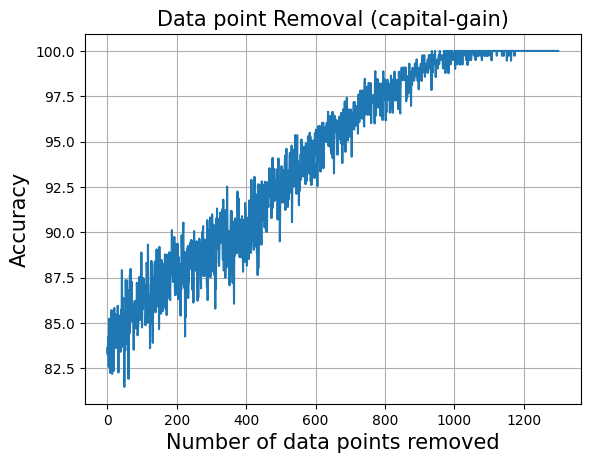

In [29]:
fig, ax = plt.subplots()

ax.plot(np.array(accuracies[:1300]) * 100)

ax.grid()
ax.set_xlabel('Number of data points removed', fontsize=15)
ax.set_ylabel('Accuracy', fontsize=15)
ax.set_title('Data point Removal (capital-gain)', fontsize=15)

# plt.savefig('Dataset Extraction - Datapoint Removal (capital-gain).png', transparent=True, bbox_inches='tight')
plt.show()

## Construct Extracted Dataset from Original Dataset

In [18]:
b = data[['age', 'education-num', 'capital-gain', 'income']].to_numpy()
a = b.copy()
for index in removed_indices[:1199]:
    a = np.delete(a, index, axis=0)

In [19]:
(a[:,3] == '<=50K').sum(), (a[:,3] == '>50K').sum()

(910, 910)

## Plot Data points Before Removal

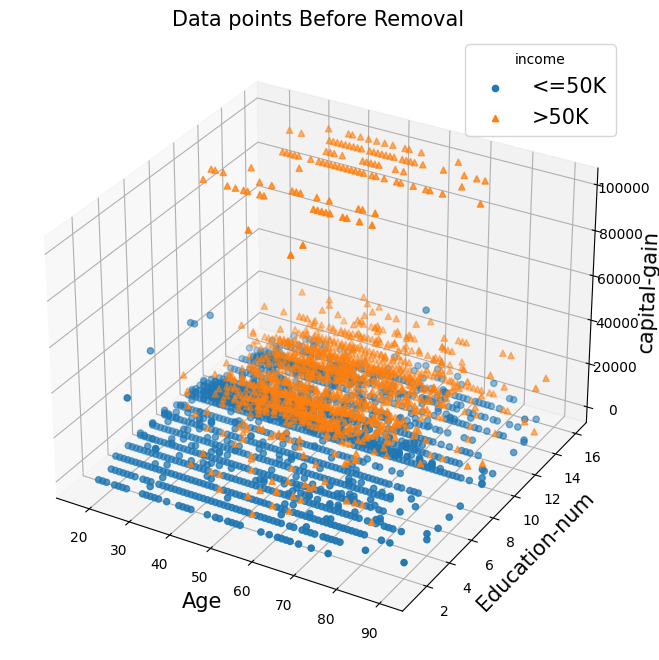

In [28]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

for marker, cls in [('o', '<=50K'), ('^', '>50K')]:
    xs = b[:, 0][b[:, 3] == cls]
    ys = b[:, 1][b[:, 3] == cls]
    zs = b[:, 2][b[:, 3] == cls]
    ax.scatter(xs, ys, zs, marker=marker, label=cls)

ax.set_xlabel('Age', fontsize=15)
ax.set_ylabel('Education-num', fontsize=15)
ax.set_zlabel('capital-gain', fontsize=15)
ax.set_title('Data points Before Removal', fontsize=15)
ax.legend(title='income', fontsize=15)

# plt.savefig('Dataset Extraction - Datapoints Before Removal.png', transparent=True, bbox_inches='tight')
plt.show()

## Plot the Data points After Removal

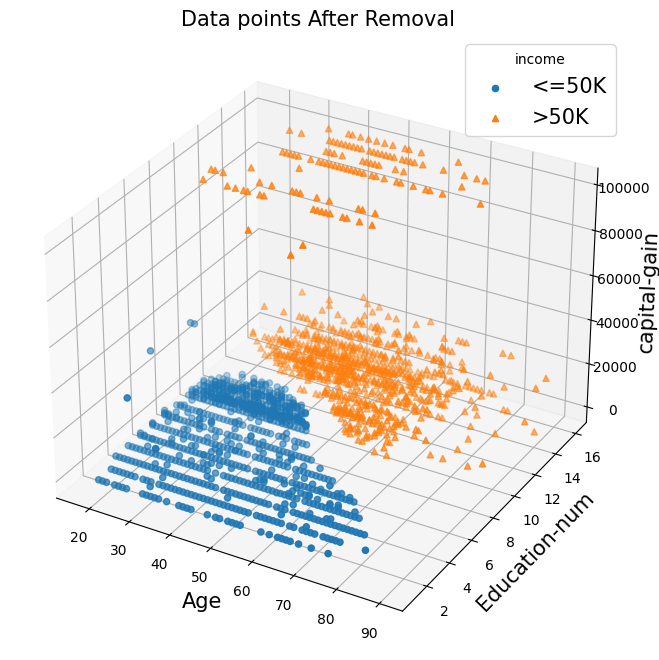

In [27]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

for marker, cls in [('o', '<=50K'), ('^', '>50K')]:
    xs = a[:, 0][a[:, 3] == cls]
    ys = a[:, 1][a[:, 3] == cls]
    zs = a[:, 2][a[:, 3] == cls]
    ax.scatter(xs, ys, zs, marker=marker, label=cls)

ax.set_xlabel('Age', fontsize=15)
ax.set_ylabel('Education-num', fontsize=15)
ax.set_zlabel('capital-gain', fontsize=15)
ax.set_title('Data points After Removal', fontsize=15)
ax.legend(title='income', fontsize=15)

# plt.savefig('Dataset Extraction - Datapoints After Removal.png', transparent=True, bbox_inches='tight')
plt.show()

In [26]:
# save extracted dataset to file
pd.DataFrame(a).to_csv('dataset.csv', header=False, index=False)